## **README: Napari Image Processing Pipeline**

Loads a raw calcium-imaging timelapse (`.imgdir` frame dump), previews it in
napari, runs a lazy (dask-backed) denoise → background-normalise →
motion-correct pipeline, then supports manual ROI drawing (napari Labels layer,
saved/loaded as `.tiff`) and per-ROI brightness → dF/F trace extraction (§4).

### **1. Dependencies**

- `napari` (+ Qt backend) — interactive viewer
- `dask` — lazy/out-of-core array stacking (`dask.array`, `dask.delayed`)
- `scikit-image` — `skimage.registration.phase_cross_correlation`;
  `skimage.restoration.denoise_nl_means` / `estimate_sigma` (denoise
  method `"nlm"`)
- `scipy` — `scipy.ndimage.gaussian_filter` (denoise method `"gaussian"`),
  `scipy.ndimage.shift`, `scipy.ndimage.percentile_filter` (dF/F baseline),
  `scipy.fft.dctn`/`idctn` (denoise method `"dct"`)
- `tifffile` — STD projection + ROI-mask `.tiff` I/O (§4)
- `zarr` — chunked on-disk store for the saved preprocessed stack (§3)
- `PyYAML` — parse `ElapsedTimes.yaml` for the real acquisition time axis
- `numpy`, `matplotlib` — array handling and static plotting
- `tqdm` *(optional)* — trace-extraction progress bar; degrades gracefully

Run in **JupyterLab/Notebook with the `%gui qt6` magic**, which starts a Qt
event loop so the napari window stays interactive alongside the notebook.

### **2. Usage / steps**

Run cells top to bottom; each section builds on viewer/array state from the
previous one.

1. **Create napari instance** — `%gui qt6`, then `napari.Viewer()` opens the
   viewer window (`viewer`).
2. **Open files** — point `data_dir` at a SlideBook-style `*.imgdir` export
   (see §3), glob `ImageData_Ch0_TP*.npy` in timepoint order, and load the
   first frame directly with `viewer.add_image()` as a sanity check.
   - **Max projection**: a plain-Python loop takes an elementwise max across
     every frame (loads each fully into memory, one at a time) and plots it
     with matplotlib for a quick static preview.
   - **Lazy stack**: wraps each frame load in `dask.delayed` and
     `da.stack`s them into one `(n_timepoints, height, width)` dask array
     (`raw_stack`) *without* reading the data.
3. **Preprocessing** — chained lazily per-frame so the full stack is never
   materialized at once (files can exceed RAM): denoise (`DENOISE_METHOD`) →
   background-normalise (`BACKGROUND_PERCENTILE`) → rigid motion correction.
   Result (`preprocessed_stack`) is added to napari; a max projection is
   plotted for QC.
   - **Save / load**: `preprocessed_stack` can be streamed to a chunked Zarr
     store under `_preprocessed/`; in later sessions run the load cell instead
     of the denoising cell to skip preprocessing entirely.
4. **ROI selection & trace extraction** — manual, napari-Labels-based:
   1. **STD projection** — `preprocessed_stack[::5].std(axis=0)` highlights
      temporally-fluctuating (active) pixels; added as `"preprocessed_std"`,
      saved to `_projections/`, and histogrammed for QC. Reference layer for
      drawing.
   2. **ROI mask (create / load / save)** — three independent cells on a
      napari **Labels** layer (`viewer.add_labels`): (a) create a blank layer
      and hand-paint ROIs with the brush tool; (b) load an existing mask from
      `_labels/<tag>_ROI.tiff`; (c) save the current layer back to `.tiff`.
   3. **Brightness traces** — per-ROI mean-intensity trace over the full time
      axis, streamed one dask frame at a time; time axis in seconds from
      `ElapsedTimes.yaml`.
   4. **dF/F + QC plots** — dF/F via a rolling low-percentile baseline
      (`BASELINE_PERCENTILE`, `BASELINE_WINDOW_S`), shown as (A) a dF/F
      spectrograph (ROI × time heatmap, `magma`) and (B) tightly-stacked
      per-ROI dF/F line charts.
   - *Not yet implemented (stubs):* PCA grouping (v) and PCA-distance graph
     (vi).

### **3. Image format**

- **Input**: a SlideBook-exported `*.imgdir` directory containing
  `ImageData_Ch0_TP########.npy` (one file per timepoint, shape `(1, H, W)`,
  `uint16`; observed `(1024, 1376)` after dropping the plane axis), per-frame
  `HistogramData_*` (unused), and `*.yaml` metadata. `ElapsedTimes.yaml` (a
  leading frame-count entry, then per-frame elapsed times in ms) *is* parsed in
  §4 to build the seconds time axis; the rest are not.
- **In-memory/lazy**: raw and preprocessed stacks are dask arrays of shape
  `(n_timepoints, height, width)`, chunked one frame at a time; preprocessing
  casts to `float32`.

### **4. Output format**

- **Persisted to disk**:
  - `preprocessed/<tag>_<method>.zarr` (+ a `.params.json` sidecar) — the full
    preprocessed stack (§3), streamed one frame per chunk. Lets future sessions
    skip the denoise+motion-correction step via the §3 load cell.
  - `projections/<tag>_std_projection.tiff` — STD projection of the
    preprocessed stack (`tifffile`, §4).
  - `labels/<tag>_ROI.tiff` — hand-drawn ROI Labels mask (`uint16`,
    `tifffile`, §4), the round-trip artifact for manual ROI selection.
- **In-memory only**: `raw_stack`, per-ROI `roi_traces` and `dff_traces`.
- Static QC figures (max/STD projections, STD histogram, dF/F spectrograph,
  stacked dF/F traces) are rendered inline via matplotlib, not saved to file.
- No spike-inference step is run here — it only prepares the imaging stack and
  per-ROI traces. Per `CLAUDE.md`, keep raw and processed data separate from any
  later inferred-spike output, and log preprocessing parameters (`DENOISE_METHOD`
  + method-specific params, `BACKGROUND_PERCENTILE`, and the §4
  `BASELINE_PERCENTILE` / `BASELINE_WINDOW_S`) alongside saved results.

## **0. Imports (Essential)**

In [5]:
# Main imports
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Import for ROI Selection
import tifffile

## **1. Create Napari instance**

In [6]:
# Open GUI magic command
%gui qt6

In [7]:
# Open napari
import napari

viewer = napari.Viewer()

## **2. Open Files**

**Directory:**

`./leftDRGcut-1769167239-383.imgdir`<br>
`./Debi_DRG-Streamtodisk-1769166699-997.imgdir`

### **Loader**

In [8]:
# Select local file directory
DATA_DIR = Path("./datasets/Debi_DRG-Streamtodisk-1769166699-997.imgdir")

In [9]:
image_files = sorted(DATA_DIR.glob("ImageData_Ch0_TP*.npy"))
print(f"Found {len(image_files)} timepoints")

first_frame = np.load(image_files[0])[0]  # drop the singleton plane axis
print(first_frame.shape, first_frame.dtype)

# Visualise the first image file
viewer.add_image(first_frame, name="frame_0000")

Found 3220 timepoints
(1024, 1376) uint16


<Image layer 'frame_0000' at 0x11a2bca90>

Loads image files onto Napari. Note that a Napari window should have popped up and now displaying the selected images.

In [10]:
# Load the filestack with lazy loading enabled
import dask
from dask import delayed
import dask.array as da

@delayed
def load_frame(path):
    return np.load(path)[0]


frame_shape = first_frame.shape
frame_dtype = first_frame.dtype

lazy_frames = [
    da.from_delayed(load_frame(f), shape=frame_shape, dtype=frame_dtype)
    for f in image_files
]
raw_stack = da.stack(lazy_frames, axis=0)
print(raw_stack)  # (n_timepoints, height, width) -- not yet loaded into memory

viewer.add_image(raw_stack, name="raw_stack")

dask.array<stack, shape=(3220, 1024, 1376), dtype=uint16, chunksize=(1, 1024, 1376), chunktype=numpy.ndarray>


<Image layer 'raw_stack' at 0x314462650>

### **Max Projection (Optional)**

In [11]:
# Produce a max-stacked image from raw dataset
original_max_stack = np.zeros(first_frame.shape, dtype=first_frame.dtype)
for f in image_files:
    frame = np.load(f)[0]
    np.maximum(original_max_stack, frame, out=original_max_stack)

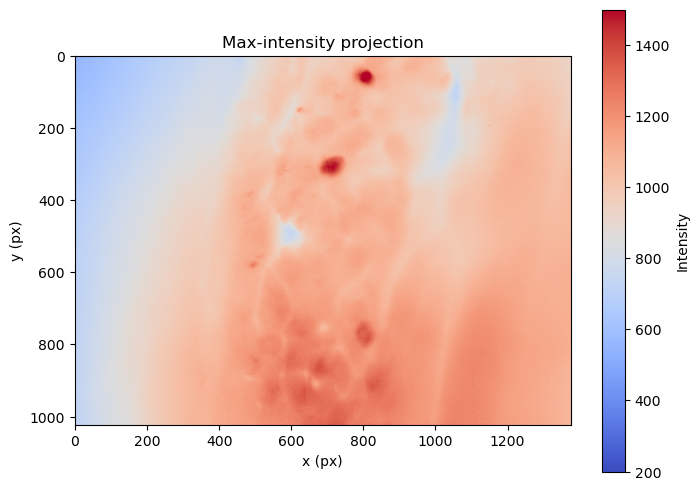

In [12]:
# Plot Figure
plt.figure(figsize=(8, 6))
plt.imshow(original_max_stack, cmap="coolwarm", vmin=200, vmax=1500)
plt.colorbar(label="Intensity")
plt.title("Max-intensity projection")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.show()

## **3. Preprocessing**

**Steps:**
1) Denoising — set `DENOISE_METHOD` to one of:
   - `"gaussian"` (default) — `scipy.ndimage.gaussian_filter`, `DENOISE_SIGMA`
   - `"nlm"` — non-local means, `skimage.restoration.denoise_nl_means`
     ([example](https://scikit-image.org/docs/stable/auto_examples/filters/plot_nonlocal_means.html)),
     noise level auto-estimated per-frame via `skimage.restoration.estimate_sigma`
   - `"dct"` — discrete cosine transform hard-thresholding via `scipy.fft.dctn`/`idctn`,
     `DCT_THRESHOLD_FRACTION`
2) Normalise to Background
3) Motion Correction

Note that files may be larger than RAM size.

### **Preprocess Settings**

In [13]:
# CONSTANTS
DENOISE_METHODS = ("gaussian", "nlm", "dct")
DENOISE_METHOD = "nlm"  # comma separated methods, all indicated methods are used

DENOISE_SIGMA = 3.0  # gaussian

NLM_PATCH_SIZE = 5  # nlm: size (px) of patches used for patch distance comparison
NLM_PATCH_DISTANCE = 6  # nlm: max px distance to search for similar patches
NLM_H_FACTOR = 1.25  # nlm: cut-off distance, scaled by the estimated noise sigma

DCT_THRESHOLD_FRACTION = 0.05  # dct: coefficients below this fraction of the max |coefficient| are zeroed

BACKGROUND_PERCENTILE = 4 # for normalisation

### **Run Denoising**

In [14]:
# Denoising, background normalisation and motion correction, chained lazily
# so the full (n_timepoints, height, width) stack is never held in RAM at once.
from scipy.ndimage import gaussian_filter, shift as nd_shift
from scipy.fft import dctn, idctn
from skimage.registration import phase_cross_correlation
from skimage.restoration import denoise_nl_means, estimate_sigma


def denoise_frame_gaussian(frame, sigma=DENOISE_SIGMA):
    return gaussian_filter(frame, sigma=sigma)


def denoise_frame_nlm(frame, patch_size=NLM_PATCH_SIZE, patch_distance=NLM_PATCH_DISTANCE, h_factor=NLM_H_FACTOR):
    # https://scikit-image.org/docs/stable/auto_examples/filters/plot_nonlocal_means.html
    sigma_est = estimate_sigma(frame, channel_axis=None)
    return denoise_nl_means(
        frame,
        h=h_factor * sigma_est,
        sigma=sigma_est,
        fast_mode=True,
        patch_size=patch_size,
        patch_distance=patch_distance,
        channel_axis=None,
    )


def denoise_frame_dct(frame, threshold_fraction=DCT_THRESHOLD_FRACTION):
    # Whole-frame 2D DCT. Hard-threshold small-magnitude AC coefficients
    # (high-frequency noise), then invert. The DC coefficient (frame mean
    # intensity) is excluded from the threshold scale and never dropped --
    # it's usually 100-1000x larger than any AC term, so including it made
    # the threshold zero out nearly the whole AC spectrum, collapsing the
    # frame to a flat constant.
    coeffs = dctn(frame, norm="ortho")
    ac_max = np.abs(coeffs.flat[1:]).max()
    threshold = threshold_fraction * ac_max
    mask = np.abs(coeffs) < threshold
    mask[0, 0] = False
    coeffs[mask] = 0
    return idctn(coeffs, norm="ortho")


_DENOISE_FUNCS = {
    "gaussian": denoise_frame_gaussian,
    "nlm": denoise_frame_nlm,
    "dct": denoise_frame_dct,
}


def denoise_frame(frame, method=DENOISE_METHOD):
    # method is a comma-separated list, e.g. "gaussian,nlm" -> applied in sequence.
    methods = [m.strip() for m in method.split(",")]
    methods = [m for m in methods if m]  # drop empty entries from stray/trailing commas
    if not methods:
        raise ValueError(f"DENOISE_METHOD must name at least one of {DENOISE_METHODS}, got {method!r}")
    unknown = [m for m in methods if m not in _DENOISE_FUNCS]
    if unknown:
        raise ValueError(
            f"Unknown DENOISE_METHOD entr{'y' if len(unknown) == 1 else 'ies'} {unknown!r}, "
            f"expected one of {DENOISE_METHODS}"
        )
    for single_method in methods:
        frame = _DENOISE_FUNCS[single_method](frame)
    return frame


def normalise_to_background(frame, background_percentile=BACKGROUND_PERCENTILE):
    background = np.percentile(frame, background_percentile)
    return frame.astype(np.float32) - background


# Reference frame for rigid motion correction, computed once and kept in memory
reference = normalise_to_background(denoise_frame(first_frame.astype(np.float32)))


@dask.delayed
def preprocess_frame(path, reference):
    frame = np.load(path)[0].astype(np.float32)
    frame = denoise_frame(frame)
    frame = normalise_to_background(frame)
    frame_shift, _, _ = phase_cross_correlation(reference, frame, upsample_factor=10)
    frame = nd_shift(frame, frame_shift)
    frame = np.clip(frame, 0, None)
    return frame.astype(np.float32)


lazy_preprocessed = [
    da.from_delayed(preprocess_frame(f, reference), shape=reference.shape, dtype=np.float32)
    for f in image_files
]
preprocessed_stack = da.stack(lazy_preprocessed, axis=0)

viewer.add_image(preprocessed_stack, name=f"preprocessed_{DENOISE_METHOD}")

<Image layer 'preprocessed_nlm' at 0x31332cf40>

### **Max Projection (Optional)**

In [15]:
# dask-compatible max projection (works for both dask arrays and numpy arrays)
import dask.array as da

In [16]:
def max_stack(input_stack):
    first_frame = input_stack[0]
    output_img = np.zeros(first_frame.shape, dtype=first_frame.dtype)
    for img in input_stack:
        np.maximum(output_img, img, out=output_img)
    return output_img

!!! **Caution** !!!

Displaying/plotting preprocessed_max_stack can be very lengthy

In [33]:
# lazy dask max along time axis -> (height, width) dask array
print("> 'processed_stack' is Dask array")

preprocessed_max_stack = preprocessed_stack[::5].max(axis=0)
print("> Image stacking complete")

# optionally compute to a numpy array: 
# preprocessed_max_stack = preprocessed_max_stack.compute()
viewer.add_image(preprocessed_max_stack, name="preprocessed_max")

> 'processed_stack' is Dask array
> Image stacking complete


<Image layer 'preprocessed_max' at 0x35450f220>

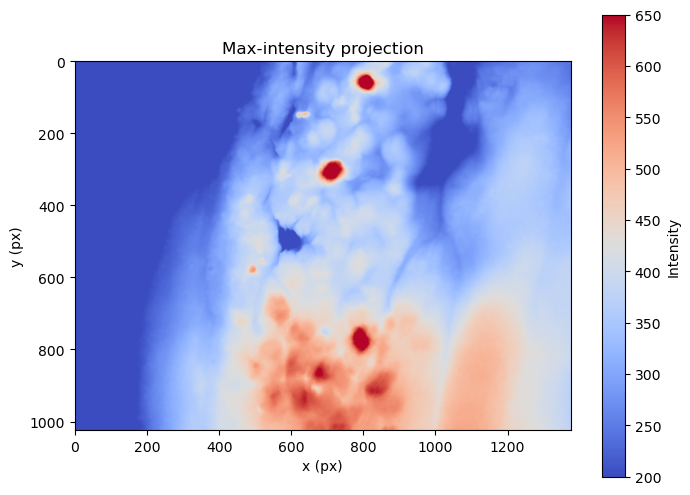

In [34]:
# Plot Figure
plt.figure(figsize=(8, 6))
plt.imshow(
    preprocessed_max_stack,
    cmap="coolwarm", vmin=200, vmax=650,
    )
plt.colorbar(label="Intensity")
plt.title("Max-intensity projection")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.show()

### **Save Preprocessed Stack**
Very lengthy run. Only run once when a new image set is imported. Afterwards, use **Load Preprocessed Stack** to load cached stack into the workflow

In [19]:
PREPROCESSED_DIR = Path("./preprocessed/")
PREPROCESSED_DIR.mkdir(exist_ok=True)

In [20]:
# SAVE (run once): persist the preprocessed stack to a chunked Zarr store so
# future sessions can skip preprocessing. Streamed one frame at a time -- the
# full (n_timepoints, H, W) float32 stack is never materialised in RAM at once.
import json as _json
from dask.diagnostics import ProgressBar

dataset_tag = DATA_DIR.name.split("-")[0]        # "Debi_DRG" from the .imgdir name
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")  # "gaussian,nlm" -> "gaussian-nlm"
preprocessed_zarr_path = PREPROCESSED_DIR / f"{dataset_tag}_{method_tag}.zarr"

# Preprocessing parameters logged alongside the data (CLAUDE.md 4).
preprocessed_params = {
    "dataset": DATA_DIR.name,
    "n_timepoints": int(preprocessed_stack.shape[0]),
    "frame_shape": list(preprocessed_stack.shape[1:]),
    "DENOISE_METHOD": DENOISE_METHOD,
    "DENOISE_SIGMA": DENOISE_SIGMA,
    "NLM_PATCH_SIZE": NLM_PATCH_SIZE,
    "NLM_PATCH_DISTANCE": NLM_PATCH_DISTANCE,
    "NLM_H_FACTOR": NLM_H_FACTOR,
    "DCT_THRESHOLD_FRACTION": DCT_THRESHOLD_FRACTION,
    "BACKGROUND_PERCENTILE": BACKGROUND_PERCENTILE,
}

# NOTE: this triggers the full preprocessing compute over every frame (slow).
with ProgressBar():
    preprocessed_stack.to_zarr(str(preprocessed_zarr_path), overwrite=True)

with open(preprocessed_zarr_path.with_suffix(".params.json"), "w") as f:
    _json.dump(preprocessed_params, f, indent=2)

print(f"> Saved preprocessed stack -> {preprocessed_zarr_path}")
print(f"> Params logged -> {preprocessed_zarr_path.with_suffix('.params.json')}")


[########################################] | 100% Completed | 497.09 s
> Saved preprocessed stack -> preprocessed/Debi_DRG_nlm.zarr
> Params logged -> preprocessed/Debi_DRG_nlm.params.json


### **Load Preprocessed Stack**

In [28]:
# Confirm load directory
dataset_tag = DATA_DIR.name.split("-")[0]
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")
print(f"To Load: {PREPROCESSED_DIR}/{dataset_tag}_{method_tag}, \nImages from dataset: {DATA_DIR}")

To Load: preprocessed/Debi_DRG_nlm, 
Images from dataset: datasets/Debi_DRG-Streamtodisk-1769166699-997.imgdir


In [30]:
# LOAD (future sessions): run this INSTEAD of the "Run Denoising" cell to
# rebuild a lazy preprocessed_stack from disk, skipping preprocessing entirely.
# Needs the §2 loader (data_dir) and Preprocess Settings (DENOISE_METHOD) cells.
import dask.array as da

dataset_tag = DATA_DIR.name.split("-")[0]
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")
preprocessed_zarr_path = (
    PREPROCESSED_DIR
    / f"{dataset_tag}_{method_tag}.zarr"
)
print(preprocessed_zarr_path)

preprocessed_stack = da.from_zarr(str(preprocessed_zarr_path))
print(f"> Loaded preprocessed stack {preprocessed_stack.shape} {preprocessed_stack.dtype} "
      f"from {preprocessed_zarr_path}")

viewer.add_image(preprocessed_stack, name=f"preprocessed_{DENOISE_METHOD}")


preprocessed/Debi_DRG_nlm.zarr
> Loaded preprocessed stack (3220, 1024, 1376) float32 from preprocessed/Debi_DRG_nlm.zarr


<Image layer 'preprocessed_nlm' at 0x344eee920>

## **4. ROI Selection**

Manually select ROI's based on the max stack created under §3, Max Projection (Optional).

### i. Save standard deviation (STD)-stacked image... (Deprecated)

### ii. Load in the ROI mask on top of the stacked image

**Run this block to save label options**

In [31]:
# Shared ROI-mask I/O settings for the create / load / save cells below.
LABELS_DIR = Path("./labels")
LABELS_DIR.mkdir(exist_ok=True)

# Base image layer whose shape/scale/translate the ROI Labels layer must match.
# "preprocessed_std" (temporal fluctuation) drives ROI drawing better than the
# max projection; swap here if you prefer another layer.
REFERENCE_IMAGE_LAYER = "preprocessed_max"

# Default load/save path, following the existing `_labels/<name>_ROI.tiff` convention.
ROI_MASK_PATH = LABELS_DIR / f"{dataset_tag}_ROI.tiff"

#### **(a) Create a new blank ROI Labels layer** — paint ROIs by hand with napari's brush tool.

In [20]:
# (a) Create a blank Labels layer sized to the reference image, then paint
# ROIs onto it with the napari brush tool (press `m` for a fresh label id
# per ROI). Run this OR the load cell below -- not both.
ref_layer = viewer.layers[REFERENCE_IMAGE_LAYER]
ref_shape = ref_layer.data.shape[-2:]

blank_mask = np.zeros(ref_shape, dtype=np.uint16)

roi_labels = viewer.add_labels(
    blank_mask,
    name="ROI mask",
    opacity=0.6,
    scale=tuple(np.atleast_1d(getattr(ref_layer, "scale", (1, 1)))[-2:]),
    translate=tuple(np.atleast_1d(getattr(ref_layer, "translate", (0, 0)))[-2:]),
)
print(f"> Created blank 'ROI mask' ({ref_shape[0]}x{ref_shape[1]}) matching "
      f"'{REFERENCE_IMAGE_LAYER}' -- paint ROIs with the brush tool.")

> Created blank 'ROI mask' (1024x1376) matching 'preprocessed_std' -- paint ROIs with the brush tool.


#### **(b) Load an existing ROI mask (`.tiff`)** — reads a rasterised Labels mask from disk and overlays it on the reference layer.

In [35]:
# (b) Load an existing ROI mask. Default location:
#     /Users/leolopster/Desktop/spike_inference/_labels/<dataset_tag>_ROI.tiff
mask = tifffile.imread(ROI_MASK_PATH)
print(f"> Loaded mask {mask.shape} {mask.dtype} from {ROI_MASK_PATH}; "
      f"{len(np.unique(mask)) - 1} ROI(s) found")

ref_layer = viewer.layers[REFERENCE_IMAGE_LAYER]
ref_shape = ref_layer.data.shape[-2:]
if mask.shape != ref_shape:
    raise ValueError(
        f"Loaded mask shape {mask.shape} != '{REFERENCE_IMAGE_LAYER}' shape {ref_shape}; "
        "check ROI_MASK_PATH / REFERENCE_IMAGE_LAYER."
    )

roi_labels = viewer.add_labels(
    mask.astype(np.uint16),
    name="ROI mask",
    opacity=0.6,
    scale=tuple(np.atleast_1d(getattr(ref_layer, "scale", (1, 1)))[-2:]),
    translate=tuple(np.atleast_1d(getattr(ref_layer, "translate", (0, 0)))[-2:]),
)

> Loaded mask (1024, 1376) int64 from labels/Debi_DRG_ROI.tiff; 59 ROI(s) found


#### **(c) Save the current ROI Labels layer** — writes the painted/edited mask back to `ROI_MASK_PATH`.

In [22]:
# (c) Save the current ROI Labels layer back to disk as a .tiff.
roi_labels = viewer.layers["ROI mask"]  # the Labels layer created/edited above

tifffile.imwrite(ROI_MASK_PATH, roi_labels.data.astype(np.uint16))
print(f"> Saved 'ROI mask' ({roi_labels.data.shape}, "
      f"{len(np.unique(roi_labels.data)) - 1} ROI(s)) -> {ROI_MASK_PATH}")

> Saved 'ROI mask' ((1024, 1376), 40 ROI(s)) -> /Users/leolopster/Desktop/spike_inference/_labels/Debi_DRG_ROI.tiff


### iii. Create brightness traces along the time axis for each ROI, based on `preprocessed_stack`

In [36]:
# Real per-frame acquisition times (seconds) from the .imgdir metadata, used as
# the shared time axis for every trace plot below. ElapsedTimes.yaml stores a
# list whose first entry is the frame count, followed by one elapsed time (ms)
# per frame.
import yaml

with open(DATA_DIR / "ElapsedTimes.yaml") as f:
    _elapsed = yaml.safe_load(f)["theElapsedTimes"]

times_ms = np.asarray(_elapsed[1:], dtype=float)  # drop leading count entry
n_timepoints = preprocessed_stack.shape[0]
if len(times_ms) != n_timepoints:
    # Fall back to a nominal 10 Hz axis if metadata length disagrees with the stack.
    print(f"! ElapsedTimes has {len(times_ms)} entries but stack has {n_timepoints} frames; "
          "falling back to a nominal 10 Hz time axis.")
    times_s = np.arange(n_timepoints, dtype=float) / 10.0
else:
    times_s = (times_ms - times_ms[0]) / 1000.0

print(f"> Time axis: {n_timepoints} frames, {times_s[-1]:.1f} s total, "
      f"~{1.0 / np.median(np.diff(times_s)):.1f} Hz median")

> Time axis: 3220 frames, 322.2 s total, ~10.0 Hz median


In [37]:
# Select starting timepoint and number of timepoints to extract
START_TIMEPOINT = 0
EXTRACT_TIMEPOINTS = 500

# Check validity of timepoint configuration
START_TIMEPOINT = int(max(0, START_TIMEPOINT))
EXTRACT_TIMEPOINTS = int(max(0, EXTRACT_TIMEPOINTS))

# Per-ROI mean-intensity (brightness) trace over the full time axis, streamed
# one dask frame at a time so the whole (n_timepoints, H, W) float32 stack is
# never materialised in RAM at once.
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

def extract_roi_traces(stack, mask, start_t, extract_timepoints):
    """Return {roi_id: (n_timepoints,) float32 mean-intensity trace}."""
    n_t = min(stack.shape[0], start_t + extract_timepoints)
    roi_ids = [int(r) for r in np.unique(mask) if r != 0]
    # Precompute pixel indices per ROI once -- avoids re-masking every frame.
    roi_indices = {roi_id: np.where(mask == roi_id) for roi_id in roi_ids}
    traces = {roi_id: np.zeros(n_t, dtype=np.float32) for roi_id in roi_ids}

    for t in tqdm(range(start_t, start_t + n_t), desc="Extracting ROI traces"):
        frame = np.asarray(stack[t])  # materialise exactly one frame
        for roi_id in roi_ids:
            yy, xx = roi_indices[roi_id]
            traces[roi_id][t] = frame[yy, xx].mean()
    return traces


roi_mask = viewer.layers["ROI mask"].data
roi_traces = extract_roi_traces(preprocessed_stack, roi_mask, START_TIMEPOINT, EXTRACT_TIMEPOINTS)
print(f"> Extracted {len(roi_traces)} ROI traces (Starting from timepoint {START_TIMEPOINT}, {EXTRACT_TIMEPOINTS} timepoints each)")

Extracting ROI traces: 100%|██████████| 500/500 [00:02<00:00, 178.82it/s]

> Extracted 59 ROI traces (Starting from timepoint 0, 500 timepoints each)


### iv. Create dF/F (F: brightness) traces for each ROI from obtained brightness traces

In [38]:
# No. of slides at the beginning of each trace used to calculate the baseline F0
BASELINE_SLIDES = 20

# Calculate dF/F for each ROI
dff_dict = {}
for roi, trace in roi_traces.items():
    f0 = np.average(trace[:BASELINE_SLIDES])
    new_trace = (trace - f0) / f0
    dff_dict[roi] = new_trace

# Stack into a (n_rois, n_timepoints) matrix for the plots below. np.array on
# dict_values gives a 0-d object array, so go via an explicit ordered list --
# roi_ids fixes the row order and labels every plot consistently.
roi_ids = sorted(dff_dict)
dff_matrix = np.vstack([dff_dict[roi] for roi in roi_ids])

# The traces cover only the extracted window (START_TIMEPOINT, EXTRACT_TIMEPOINTS),
# which is shorter than the full ElapsedTimes axis -- clip times_s to match.
t_plot = times_s[START_TIMEPOINT:START_TIMEPOINT + dff_matrix.shape[1]]

print(f"> dF/F for {len(roi_ids)} ROI(s) x {dff_matrix.shape[1]} frames "
      f"({t_plot[0]:.1f}-{t_plot[-1]:.1f} s); "
      f"range [{dff_matrix.min():.2f}, {dff_matrix.max():.2f}]")

> dF/F for 59 ROI(s) x 500 frames (0.0-49.9 s); range [-0.10, 1.07]


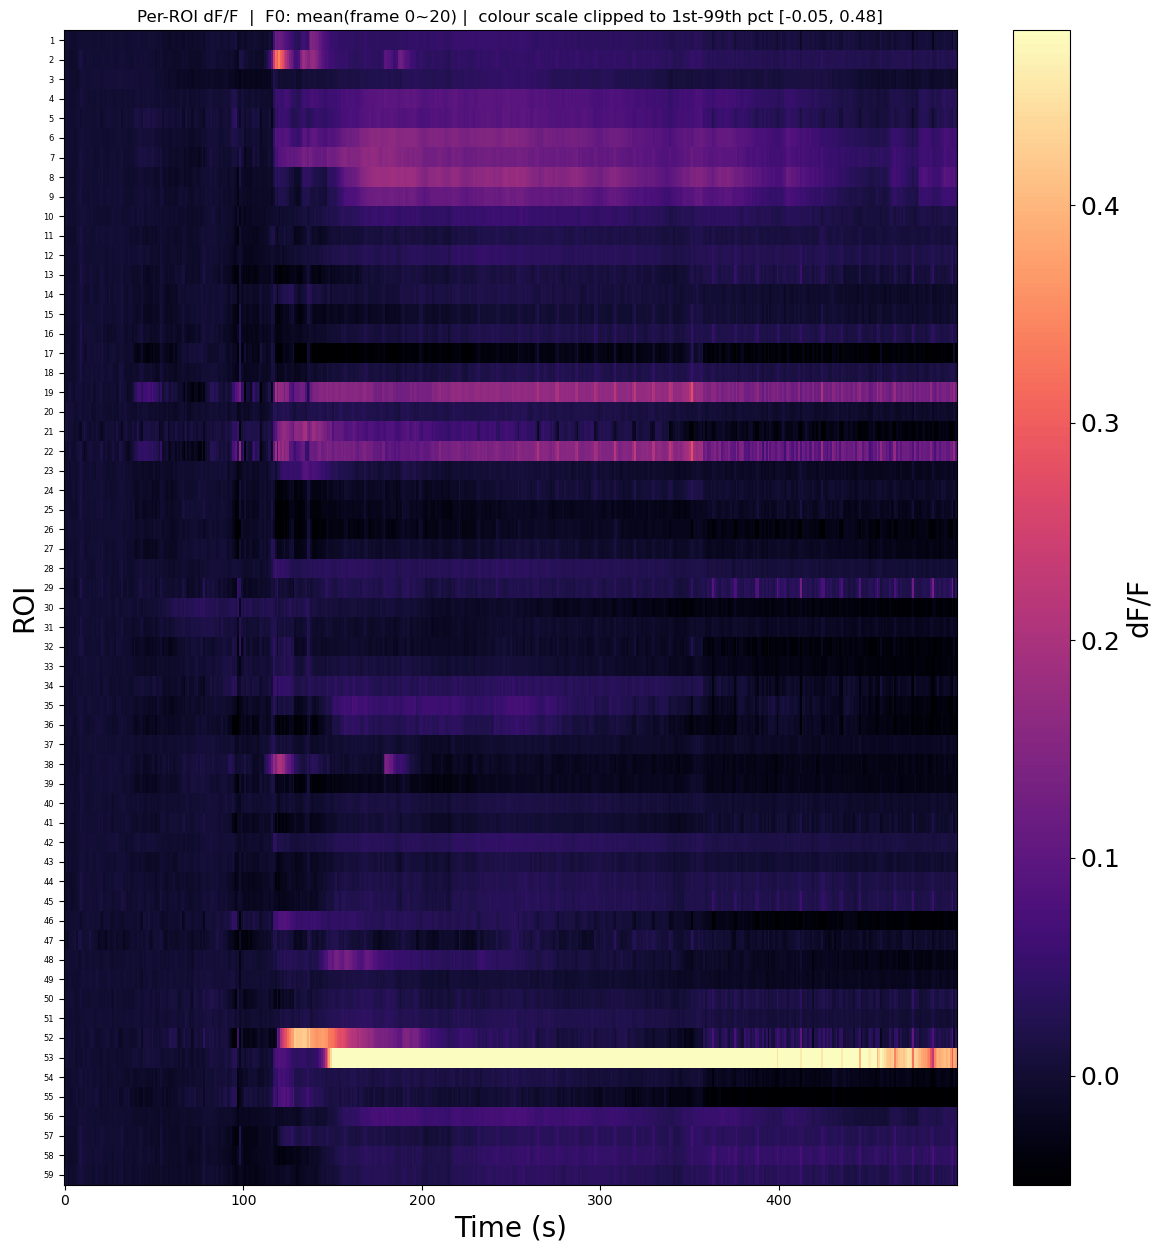

In [46]:
# QC plot A -- dF/F spectrograph: one row per ROI, x = time (s), pixel = dF/F.
# Rows come from dff_dict via roi_ids/dff_matrix (F0 = mean of the first
# BASELINE_SLIDES frames). magma (perceptually uniform) per CLAUDE.md 5; jet is avoided.

# Robust colour limits -- without them a couple of large transients compress
# every other ROI to black. The scale is clipped, not neutral, so it is stated
# in the title.
vmin, vmax = np.percentile(dff_matrix, [1, 99])

fig, ax = plt.subplots(figsize=(12, 0.18 * len(roi_ids) + 2))
im = ax.imshow(
    dff_matrix,
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
    # extent=[t_plot[0], t_plot[-1], len(roi_ids) - 0.5, -0.5],
)
ax.set_yticks(range(len(roi_ids)))
ax.set_yticklabels([str(r) for r in roi_ids], fontsize=6)
ax.set_xlabel("Time (s)", fontsize=20)
ax.set_ylabel("ROI", fontsize=20)
ax.set_title(
    f"Per-ROI dF/F  |  F0: mean(frame 0~{BASELINE_SLIDES}) |  "
    f"colour scale clipped to 1st-99th pct [{vmin:.2f}, {vmax:.2f}]"
)
cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('dF/F', size=20)

plt.tight_layout()
plt.show()


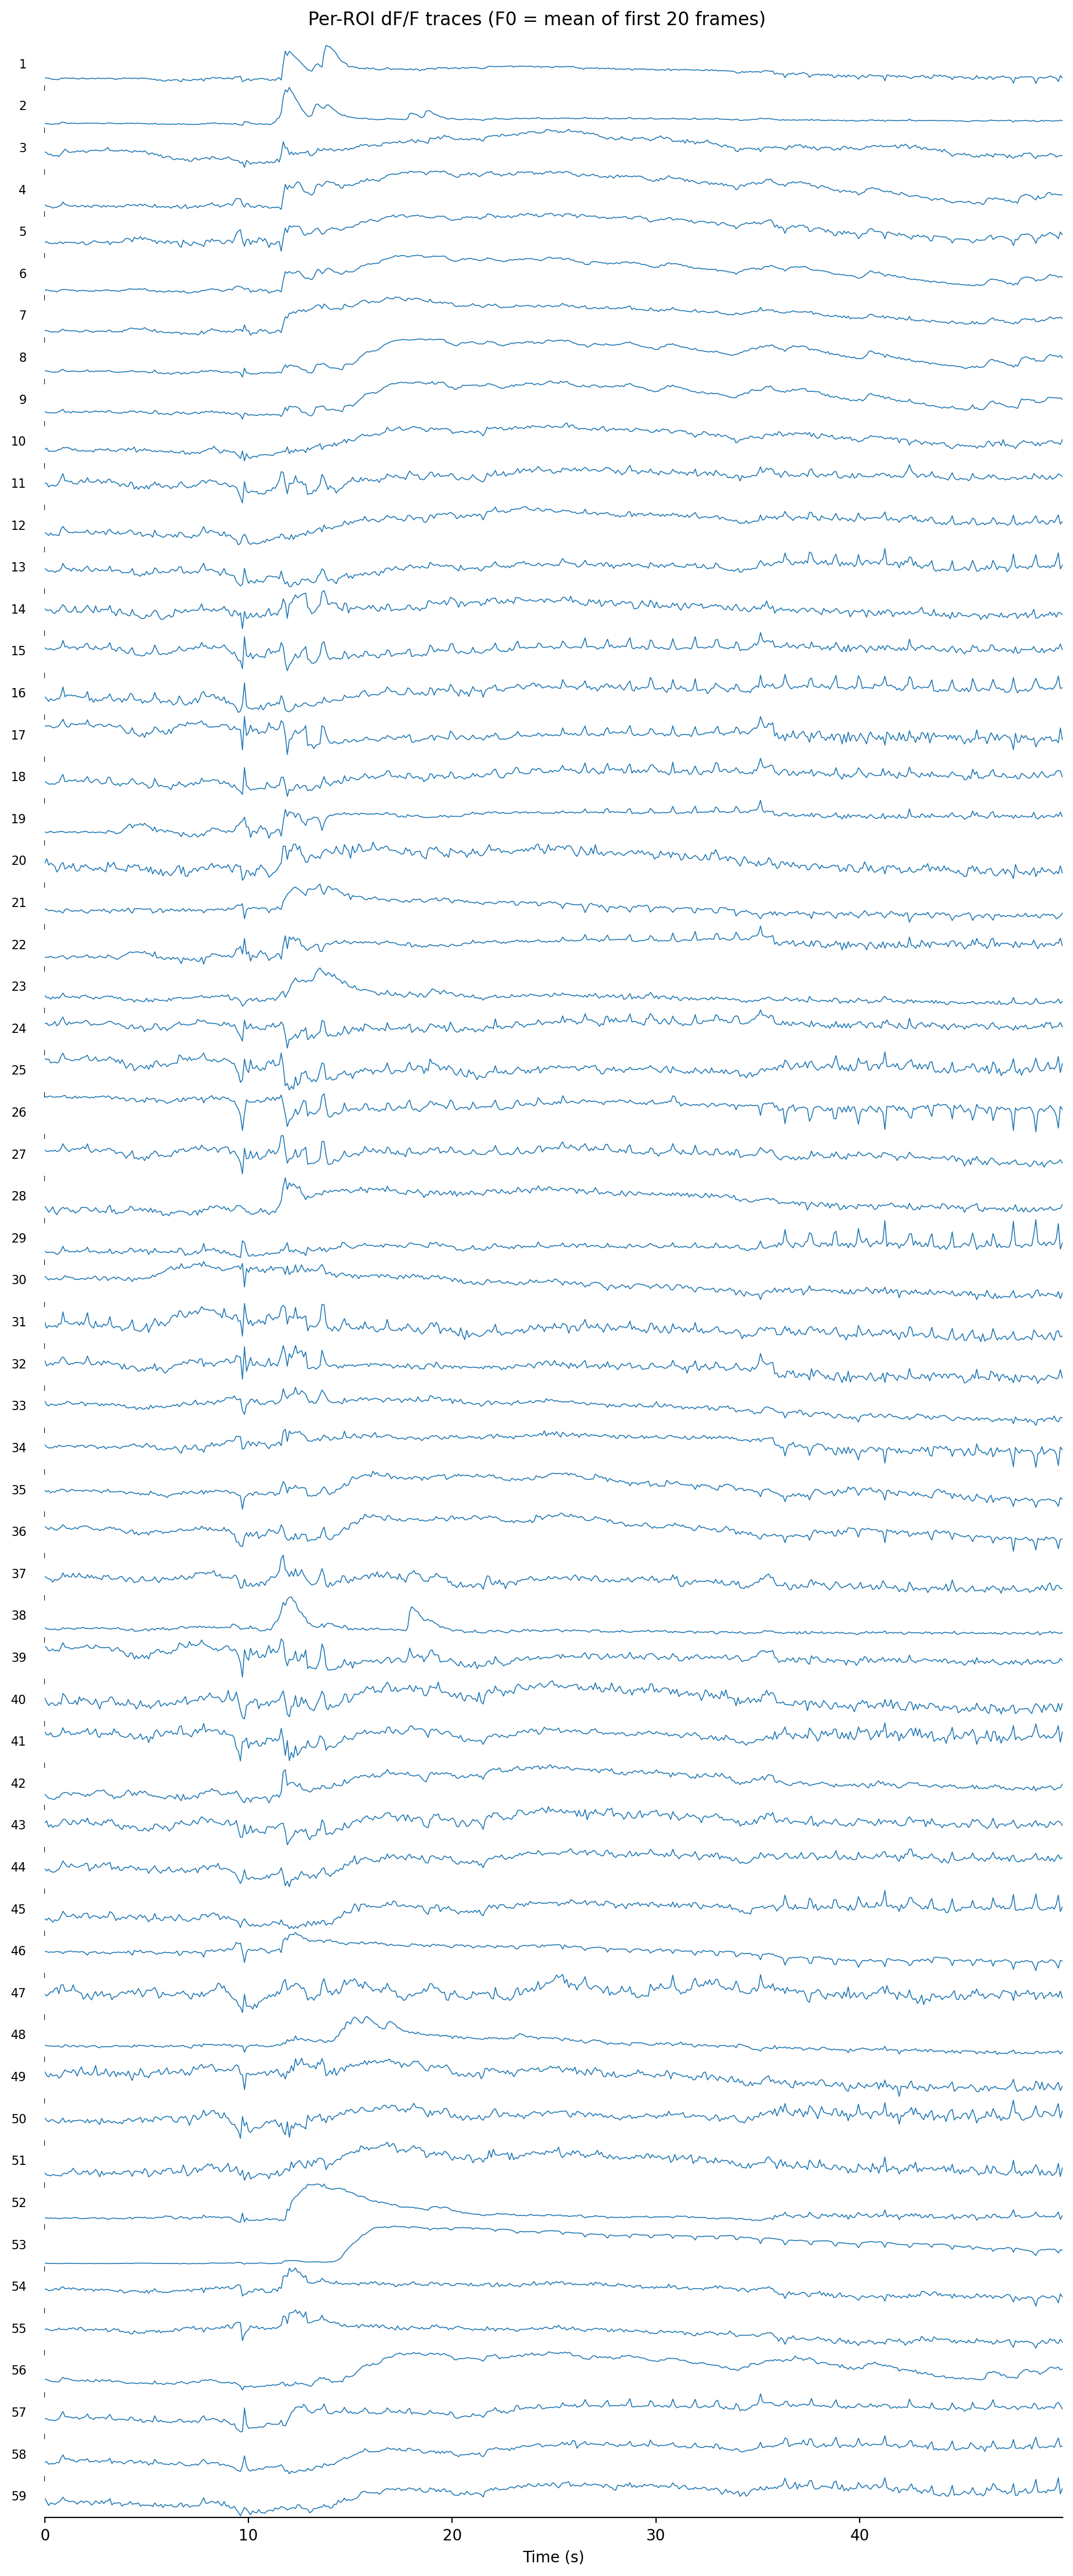

In [47]:
# QC plot B -- stacked dF/F line charts: one subplot per ROI, tightly stacked,
# trace only (no grid, no spines/ticks), ROI number in the left padding.
n_rois = len(roi_ids)
fig_h = 0.4 * n_rois
fig, axes = plt.subplots(
    n_rois, 1, sharex=True, figsize=(12, fig_h), dpi=200
)
axes = np.atleast_1d(axes)

# Margins in absolute inches, converted to figure fractions. matplotlib's
# defaults are fractions (top=0.88), so on a figure whose height grows with
# n_rois they turn into inches of blank space above the first trace.
TOP_IN, BOTTOM_IN = 0.45, 0.55  # room for the suptitle / the shared x-axis
fig.subplots_adjust(
    hspace=0,
    top=1 - TOP_IN / fig_h,
    bottom=BOTTOM_IN / fig_h,
)

for ax, roi_id in zip(axes, roi_ids):
    ax.plot(t_plot, dff_dict[roi_id], linewidth=0.6)
    ax.margins(x=0)
    ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_ylabel(str(roi_id), rotation=0, ha="right", va="center", labelpad=12, fontsize=8)

# only the bottom subplot carries the shared time axis
axes[-1].spines["bottom"].set_visible(True)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Per-ROI dF/F traces (F0 = mean of first {BASELINE_SLIDES} frames)",
    y=1 - 0.15 / fig_h, va="top",
)
plt.show()


## **5. Analysis and Summary**

Groups the ROIs in `dff_matrix` by **when** they respond and **how fast** they fluctuate, in
two independent passes over the same neurons:

- **Index A — inferred spike rate.** CASCADE converts each dF/F trace into an inferred rate;
  that rate is summarised per stimulus phase, then PCA + hierarchical clustering groups the
  ROIs. *Reported first.*
- **Index B — event frequency.** Per-phase FFT band powers of the same inferred rate, fed to
  a **separate** PCA + clustering on the same ROIs.

The two indices are kept in separate PCAs on purpose: pooling rate and frequency features
into one decomposition yields PCs that are a blend of both and can be read as neither. The
last cell compares the two groupings.

| Phase | Window | Note |
|---|---|---|
| pre | 2–10 s | starts at 2 s to exclude the frames that defined F0 |
| stim | 10–15 s | shortest phase — sets the 0.2 Hz frequency resolution floor |
| post | 15–50 s | truncated to ~49.9 s by `EXTRACT_TIMEPOINTS`; contains the decay tail |

### How this section is laid out

- **All constants live in the configuration cell below** — model, phases, bands, thresholds,
  cut heights, plotting options. Change the analysis there; the cells after it only
  orchestrate.
- **The heavy code lives in `./analysis_tools/`**, not in the notebook:
  `cascade_runner.py` (model selection, resampling, inference), `features.py` (Index A and
  Index B tables), `grouping.py` (PCA + Ward clustering), `plots.py` (figures). `%autoreload`
  is on, so edits to those files take effect without restarting the kernel.

**Requires** §4 iv to have run (`dff_matrix`, `roi_ids`, `t_plot`, `BASELINE_SLIDES`).
**Outputs** go to `analysis/<dataset_tag>/`: `spike_rate.npy`, `spike_inference_params.json`,
`rate_features.csv`, `freq_features.csv`, `roi_groups.csv`.

Read the Caveats cell at the end before quoting any number out of this section.

In [69]:
# =============================================================================
# §5 0. CONFIGURATION -- every constant used in Section 5 lives in this cell.
# Edit here; the cells below only orchestrate calls into ./analysis_tools/.
# =============================================================================
# autoreload so edits to ./analysis_tools/*.py take effect without restarting the kernel
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd

import analysis_tools as at   # ./analysis_tools/{cascade_runner,features,grouping,plots}.py

# --- paths -------------------------------------------------------------------
CASCADE_DIR = Path("./CascadeTorch")
CASCADE_MODEL_DIR = CASCADE_DIR / "Pretrained_models"
ANALYSIS_DIR = Path("./analysis") / dataset_tag

# --- stimulus phases (seconds) ----------------------------------------------
# `pre` starts at 2.0 s, not 0: frames 0..BASELINE_SLIDES defined F0, so dF/F over
# that span is ~0 by construction and would fake a perfectly silent baseline.
PHASES = {
    "pre": (2.0, 10.0),
    "stim": (10.0, 15.0),
    "post": (15.0, 50.0),
}
PHASE_ORDER = list(PHASES)

# --- spike inference ---------------------------------------------------------
# The model's training rate is parsed from its NAME. If it differs from the
# acquisition rate, traces are resampled to it and the inferred rate resampled
# back, so every window below stays on the real acquisition grid.
MODEL_NAME = "Spinal_cord_excitatory_30Hz_smoothing50ms"

# --- Index A: inferred spike rate -------------------------------------------
ACTIVE_THRESH = None    # spikes/s. None -> baseline median + ACTIVE_N_SIGMA robust sigma.
ACTIVE_N_SIGMA = 3.0    # A fixed absolute value does not transfer between models.

# --- Index B: event frequency ------------------------------------------------
# Lower edge = FFT bin width of the SHORTEST phase (5 s stim -> 0.2 Hz);
# upper edge = Nyquist of the acquisition rate. Slower components are excluded
# by design, because they are not resolvable inside every phase.
FREQ_BANDS = [(0.2, 0.5), (0.5, 1.0), (1.0, 2.0), (2.0, 5.0)]

# --- PCA + hierarchical clustering (shared by both indices, fitted separately) --
PCA_VAR_TARGET = 0.80   # keep the PCs reaching this cumulative variance
MAX_K = 8               # largest k considered in the candidate-cut table
MIN_GROUP_SIZE = 3      # a "group" of 1-2 ROIs is an outlier, not a population
MAX_GROUP_FRAC = 0.9    # ...and one group holding almost everything is not a partition
RATE_CUT_HEIGHT = 10.5  # None -> auto; else a height from the §5 vi candidate table
FREQ_CUT_HEIGHT = None  # None -> auto; else a height from the §5 x candidate table

# --- plotting ----------------------------------------------------------------
SHOW_ROI_TRACES = True  # draw each member ROI behind the group mean
ROI_TRACE_ALPHA = 0.3

# --- derived (not a knob) ----------------------------------------------------
FRAME_RATE = 1.0 / float(np.median(np.diff(t_plot)))

print(f"> {len(roi_ids)} ROIs x {dff_matrix.shape[1]} frames @ {FRAME_RATE:.2f} Hz "
      f"({t_plot[0]:.1f}-{t_plot[-1]:.1f} s)")
print(f"> Model: {MODEL_NAME}")
print(f"> Outputs -> {ANALYSIS_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
> 59 ROIs x 500 frames @ 10.00 Hz (0.0-49.9 s)
> Model: Spinal_cord_excitatory_30Hz_smoothing50ms
> Outputs -> analysis/Debi_DRG


In [65]:
# §5 i. Stimulus phase windows, shared by everything below (constants in §5 0).
phase_masks = at.features.phase_masks(t_plot, PHASES)
at.features.describe_phases(t_plot, PHASES, phase_masks, FRAME_RATE)

> pre   requested   2.0-10.0  s | realised   2.0-9.9   s,  80 frames
> stim  requested  10.0-15.0  s | realised  10.0-14.9  s,  50 frames
> post  requested  15.0-50.0  s | realised  15.0-49.9  s, 350 frames
> 480 frames assigned across 3 disjoint phases; recording ends at 49.9 s, frame rate 10.00 Hz
! A phase runs to 50 s but the extraction stops at 49.9 s -- report that window as ending at 49.9 s.


### CASCADE (Spike Inference Model)

[CASCADE](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., 2021) is a CNN
ensemble that converts a dF/F trace into an inferred spike rate. The local `CascadeTorch/`
copy is used; nothing is downloaded.

- **Do not call `cascade.download_model()`.** All 24 model folders already carry their `.pth`
  weights on disk — that call only needs network access and would fail offline.
- **OpenMP workaround.** `import torch` aborts in the `cascade` env with `OMP: Error #15`
  (two copies of `libomp.dylib`). `os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"` is set
  *before* the import in the run cell. Inference runs on CPU — the workload is 59 x 500.
- **Edge padding.** The model needs a 32-frame window centred on each prediction point, so
  the first and last **16 frames (1.6 s)** come back `NaN`. That does not touch the 2–10 s
  pre window, but it does trim ~1.6 s off the end of the post window. Everything downstream
  uses `np.nanmean` / `np.nanmax`.
- **Units.** CASCADE returns spikes *per frame*; multiplying by the frame rate gives
  **spikes/s**. Output is a continuous rate, not discrete events — no threshold is applied.
- **Noise levels.** `calculate_noise_levels` reports in percent units and this model covers
  levels 2–30. Our traces are heavily denoised (gaussian σ=3 + NLM) and averaged over many
  pixels per ROI, so they may fall *below* 2 — in which case every ROI silently gets the
  lowest-noise ensemble. The run cell prints the levels so this is visible rather than assumed.
- **Model choice is a logged parameter**, not a default to inherit — see the selector below.


In [70]:
# §5 iii. Every locally available model, with the properties that decide whether it
# is applicable: the rate from its NAME, the rate in its config.yaml (they disagree
# for at least one shipped folder), and the ground-truth datasets behind it.
at.cascade_runner.describe_models(CASCADE_MODEL_DIR)

print()
model_cfg, MODEL_RATE, RESAMPLE_RATIO, NEEDS_RESAMPLE = at.cascade_runner.check_model(
    CASCADE_MODEL_DIR, MODEL_NAME, FRAME_RATE)

model                                                 name    cfg   training datasets
GC8_EXC_100Hz_smoothing10ms                          100.0  100.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_10Hz_smoothing150ms_high_noise                10.0   10.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_10Hz_smoothing75ms_high_noise                 10.0   10.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_15Hz_smoothing100ms_high_noise                15.0   15.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_15Hz_smoothing50ms_high_noise                 15.0   10.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1   <-- MISMATCH
GC8_EXC_20Hz_smoothing30ms_high_noise                 20.0   20.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_20Hz_smoothing60ms_high_noise                 20.0   20.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_30Hz_smoothing25ms_high

In [74]:
# §5 iv. Run CASCADE (resampling to the model rate and back if they differ).
# Implementation: analysis_tools/cascade_runner.py
result = at.cascade_runner.run(
    dff_matrix, FRAME_RATE, MODEL_NAME, CASCADE_DIR,
    model_dir=CASCADE_MODEL_DIR,
    announce_model=False,  # §5 iii already printed the plan
)
spike_rate, PAD = result.spike_rate, result.pad

if t_plot[PAD] > PHASES["pre"][0]:
    print(f"! Padding reaches {t_plot[PAD]:.1f} s, past the start of the pre window "
          f"({PHASES['pre'][0]} s) -- widen PHASES['pre'] or expect NaN-only frames there.")

at.cascade_runner.save(result, ANALYSIS_DIR, extra={
    "dataset": DATA_DIR.name,
    "roi_ids": [int(r) for r in roi_ids],
    "phases_s": {k: list(v) for k, v in PHASES.items()},
    "BASELINE_SLIDES": BASELINE_SLIDES,
    "START_TIMEPOINT": START_TIMEPOINT,
    "EXTRACT_TIMEPOINTS": EXTRACT_TIMEPOINTS,
})


> Noise levels at the native 10.00 Hz (percent units): median 0.11, range [0.06, 0.34]
> Model covers 2-14; 59 ROI(s) below, 0 above -> nearest ensemble.
> Resampled for inference: (59, 500) @ 10.00 Hz -> (59, 1500) @ 30 Hz
> (noise measured AFTER resampling would read 0.03 instead of 0.11 -- native value passed instead)

 
The selected model was trained on 1 datasets, with 5 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 50 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 59 neurons and 1500 frames.
Noise levels (mean, std; in standard units): 0.12, 0.05

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for this noise level

Predictions for noise level 5:
	No neu

PosixPath('analysis/Debi_DRG')

In [75]:
# §5 v. Index A -- per-phase summary of the inferred rate, one row per ROI.
if ACTIVE_THRESH is None:
    ACTIVE_THRESH, _med, _sigma = at.features.auto_active_thresh(
        spike_rate, phase_masks["pre"], ACTIVE_N_SIGMA)
    print(f"> ACTIVE_THRESH auto = {ACTIVE_THRESH:.3f} spikes/s "
          f"(pre-phase median {_med:.3f} + {ACTIVE_N_SIGMA:g}x robust sigma {_sigma:.3f})")

rate_features = at.features.rate_features(spike_rate, roi_ids, phase_masks, ACTIVE_THRESH)
dff_summary = at.features.dff_summary(dff_matrix, roi_ids, phase_masks)

n_bad = int((~np.isfinite(rate_features.to_numpy())).sum())
print(f"> Index A: {rate_features.shape[1]} features x {rate_features.shape[0]} ROIs "
      f"({n_bad} non-finite value(s) -- must be 0 before PCA)")
at.features.report_threshold(rate_features, phase_masks, ACTIVE_THRESH)
print(rate_features.describe().loc[["mean", "min", "max"]].round(3).to_string())

> ACTIVE_THRESH auto = 0.439 spikes/s (pre-phase median 0.356 + 3x robust sigma 0.028)
> Index A: 9 features x 59 ROIs (0 non-finite value(s) -- must be 0 before PCA)
> pre   ACTIVE_THRESH=0.439: 38/59 ROIs ever active, 0 always active
> stim  ACTIVE_THRESH=0.439: 51/59 ROIs ever active, 0 always active
> post  ACTIVE_THRESH=0.439: 38/59 ROIs ever active, 2 always active
      rate_mean_pre  rate_peak_pre  rate_active_frac_pre  rate_mean_stim  rate_peak_stim  rate_active_frac_stim  rate_mean_post  rate_peak_post  rate_active_frac_post
mean          0.370          0.546                 0.064           0.591           1.634                  0.377           0.458           0.895                  0.237
min           0.312          0.361                 0.000           0.297           0.330                  0.000           0.269           0.308                  0.000
max           0.506          1.496                 0.512           2.724          11.462                  0.960           3.5

> PCA-A: 9 features -> 3 PC(s) for 88% of variance


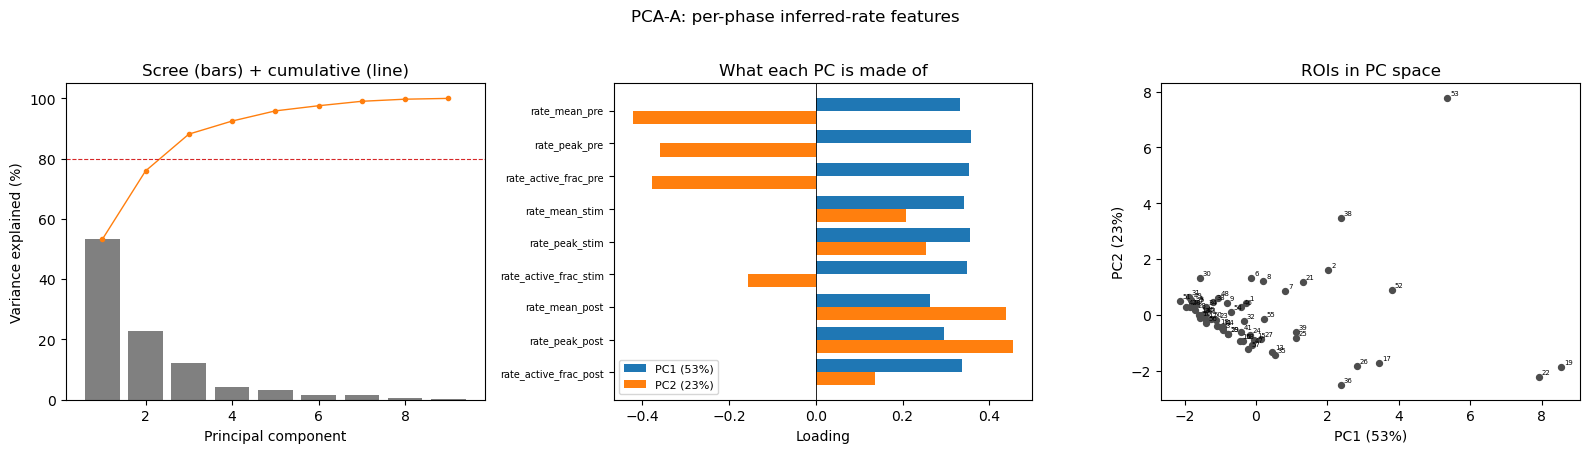


> Candidate cuts (pick one for RATE_CUT_HEIGHT in §5 0, or accept the auto choice):
   height   gap  smallest  largest                       sizes
k                                                             
2   15.39  6.84         3       56                     [56, 3]
3   11.86  0.23         1       56                  [56, 2, 1]
4   10.91  1.68         1       31              [31, 25, 2, 1]
5    8.83  2.49         1       31           [31, 23, 2, 2, 1]
6    7.22  0.72         1       31        [31, 17, 6, 2, 2, 1]
7    5.49  2.74         1       31     [31, 14, 6, 3, 2, 2, 1]
8    4.05  0.14         1       31  [31, 14, 5, 3, 2, 2, 1, 1]


In [76]:
# §5 vi. PCA-A on the rate features + the candidate cuts for §5 viii.
pca_rate, scores_rate, npc_rate, Z_rate = at.grouping.pca_and_linkage(
    rate_features, PCA_VAR_TARGET)
print(f"> PCA-A: {rate_features.shape[1]} features -> {npc_rate} PC(s) "
      f"for {100 * pca_rate.explained_variance_ratio_[:npc_rate].sum():.0f}% of variance")

at.plots.pca_summary(pca_rate, scores_rate, rate_features, roi_ids,
                     "PCA-A: per-phase inferred-rate features", PCA_VAR_TARGET)

print("\n> Candidate cuts (pick one for RATE_CUT_HEIGHT in §5 0, or accept the auto choice):")
print(at.grouping.cut_candidates(Z_rate, MAX_K).to_string())

### How to read the dendrogram

The tree is built by **Ward linkage**: start with every ROI as its own cluster, then
repeatedly merge the two clusters whose merger increases within-cluster variance the least.

- **Leaves** (bottom) are individual ROIs, labelled by ROI id.
- **Height of a horizontal bar** = the *cost* of that merge, i.e. how much within-cluster
  variance the merge added. It is **not** the distance between two ROIs — a common
  misreading. Heights grow as you go up because later merges join bigger clusters.
- **A horizontal cut** at height *h* defines the groups: every branch still unbroken below
  the cut becomes one group. Cutting lower ⇒ more, tighter groups.
- **Long vertical stems** below a merge mean the two things being joined were very different
  — a well-separated group sits under a long stem. **Short stems** mean the group barely
  holds together and would dissolve at a slightly lower cut.
- **Left–right order of leaves carries no meaning.** Each merge can be drawn either way
  round, so "adjacent in the plot" does not imply "similar". Only vertical structure counts.

**Practical rule:** cut just below the largest vertical gap — the tallest stretch of tree
with no merges. That is the height where clusters stay stable over the widest range, so the
grouping is least sensitive to exactly where you cut.

The cells below print a **candidate-cut table** (`cut_candidates`) — for every k from 2 to 8:
the cut height, the merge gap, and the resulting group sizes. Read it alongside the tree.

`suggest_cut` picks the largest gap among the *eligible* cuts, where eligible means every
group holds at least `MIN_GROUP_SIZE` ROIs **and** no group holds more than
`MAX_GROUP_FRAC` of the population. Both guards exist because on this data the unguarded
largest-gap rule returns a non-answer: it slices off two or three extreme ROIs and calls the
remaining 95% "a group". If no cut qualifies, the fallback is the plain largest gap and the
next cell says so loudly.

To override, set `RATE_CUT_HEIGHT` / `FREQ_CUT_HEIGHT` to a height from the table and re-run —
the dashed red line in the plot shows where the cut landed.

**Caveat:** Ward assumes roughly spherical, similarly-sized clusters in the PCA space it is
given. It will always return a partition, including on data with no real group structure —
the dendrogram is a hypothesis to check against the group-mean traces below, not proof.

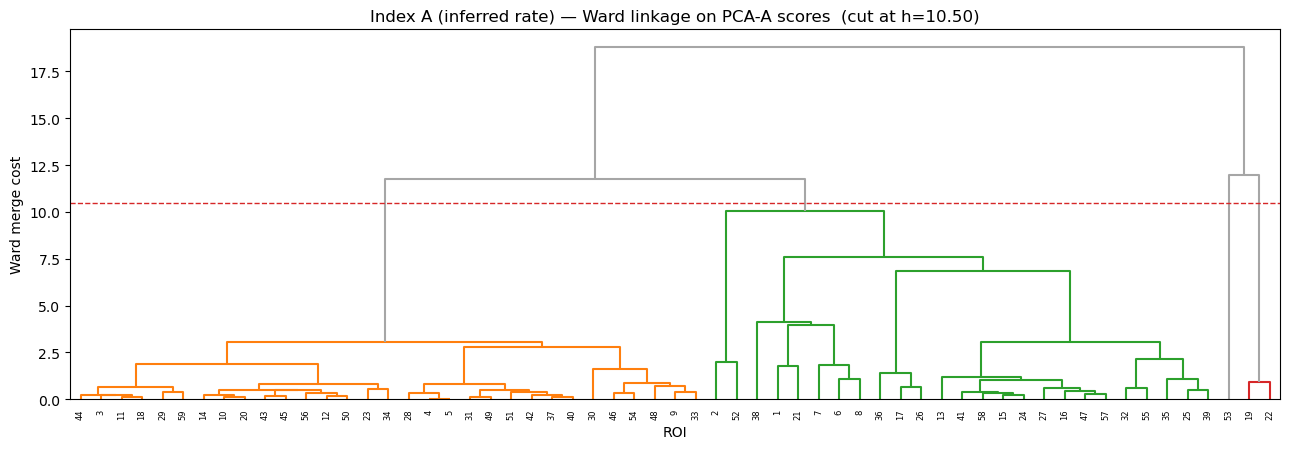

> Cut at h=10.50 -> 4 group(s): G1 n=31, G2 n=25, G3 n=2, G4 n=1


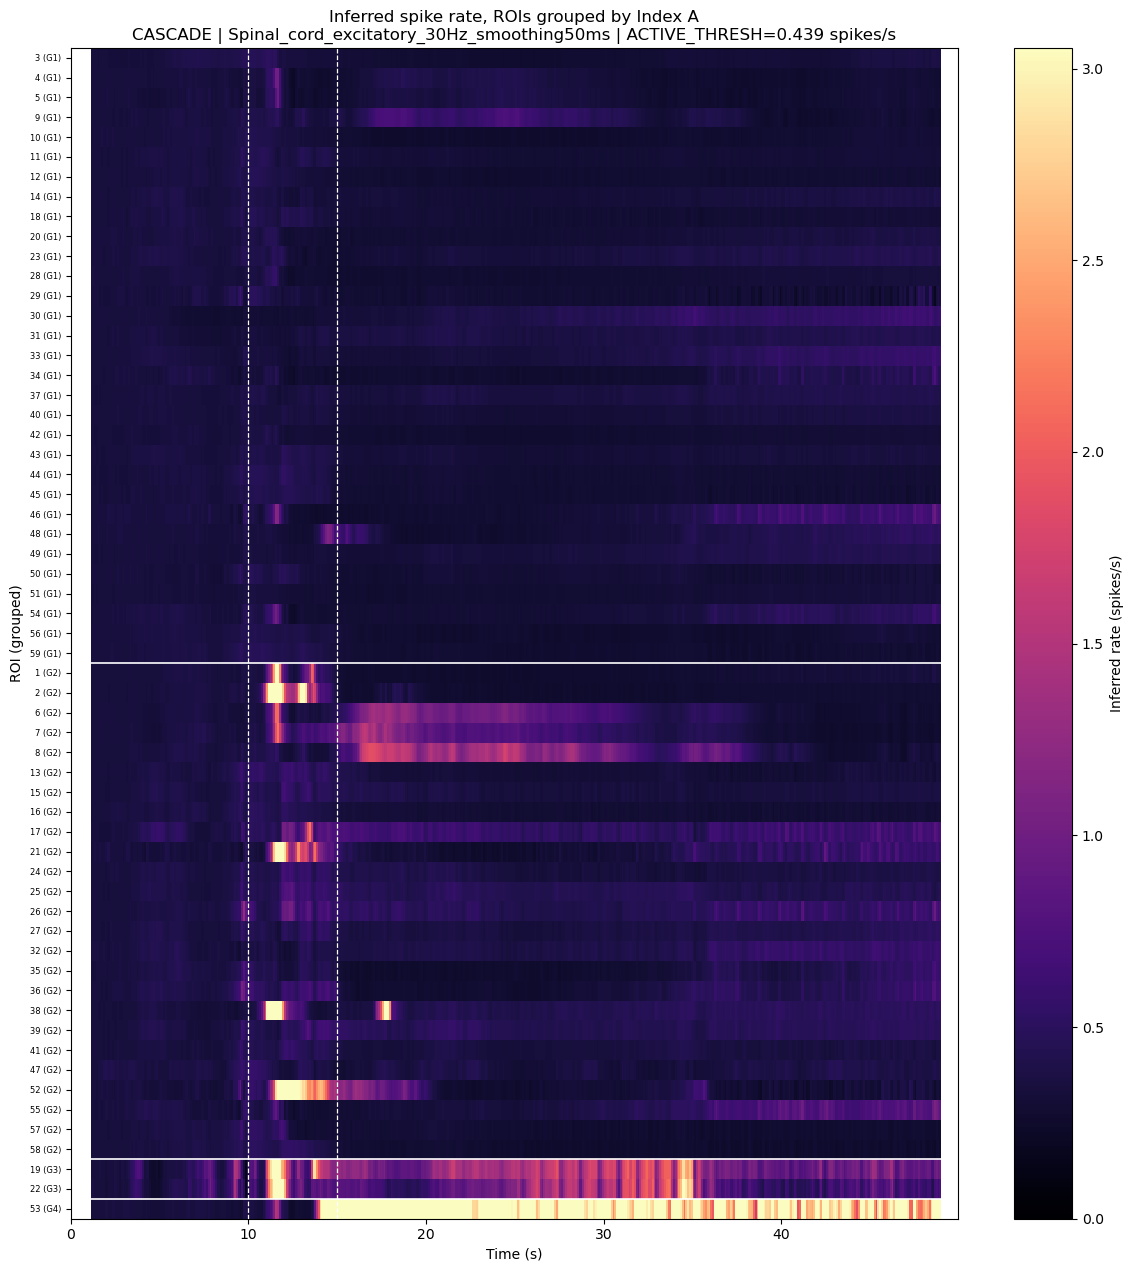

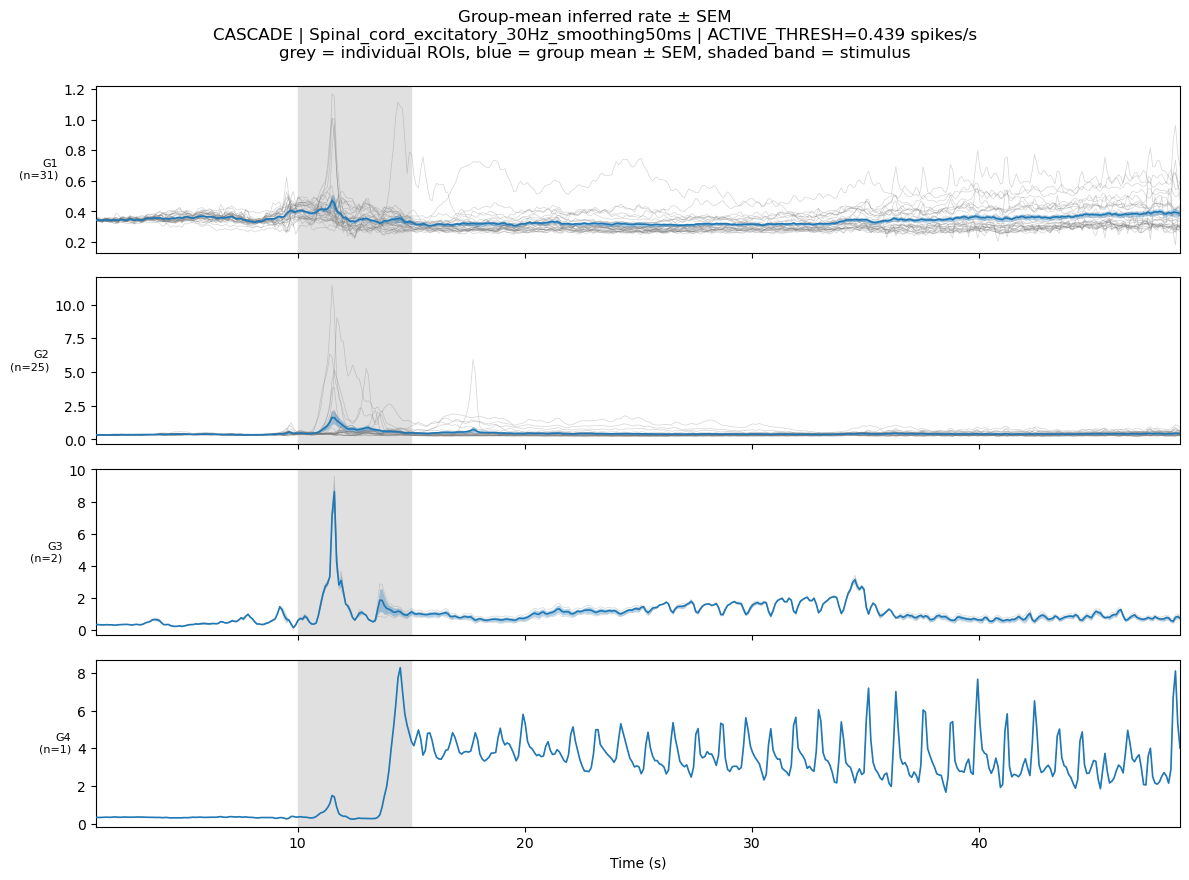


=== Rate groups (Index A) ===
CASCADE | Spinal_cord_excitatory_30Hz_smoothing50ms | ACTIVE_THRESH=0.439 spikes/s
       n_rois  rate_mean_pre  rate_peak_pre  dff_peak_pre  rate_mean_stim  rate_peak_stim  dff_peak_stim  rate_mean_post  rate_peak_post  dff_peak_post dominant_phase
group                                                                                                                                                                 
G1         31          0.356          0.444         0.017           0.369           0.552          0.037           0.337           0.469          0.051           stim
G2         25          0.378          0.604         0.023           0.745           2.150          0.079           0.430           0.955          0.075           stim
G3          2          0.495          1.469         0.146           1.599           8.626          0.192           1.117           3.150          0.275           stim
G4          1          0.344          0.394        

2026-08-05 13:19:19.582 python[66153:6846840] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


In [77]:
# §5 viii. Cut the rate tree into groups, then characterise what each group does.
cut_rate = RATE_CUT_HEIGHT if RATE_CUT_HEIGHT is not None else at.grouping.suggest_cut(
    Z_rate, MAX_K, MIN_GROUP_SIZE, MAX_GROUP_FRAC)

at.plots.dendrogram_plot(Z_rate, roi_ids,
                         "Index A (inferred rate) — Ward linkage on PCA-A scores", cut_rate)
rate_groups = at.grouping.cut_tree(Z_rate, cut_rate, roi_ids, MAX_GROUP_FRAC,
                                   label="inferred-rate")

label = f"CASCADE | {MODEL_NAME} | ACTIVE_THRESH={ACTIVE_THRESH:.3f} spikes/s"

at.plots.rate_heatmap(spike_rate, t_plot, roi_ids, rate_groups, PHASES["stim"],
                      f"Inferred spike rate, ROIs grouped by Index A\n{label}")

at.plots.group_means(spike_rate, t_plot, rate_groups, roi_ids, PHASES["stim"], PAD,
                     f"Group-mean inferred rate ± SEM\n{label}",
                     show_rois=SHOW_ROI_TRACES, roi_alpha=ROI_TRACE_ALPHA)

rate_summary = at.features.group_summary(rate_features, dff_summary, rate_groups, PHASE_ORDER)
print("\n=== Rate groups (Index A) ===")
print(label)
print(rate_summary.to_string())
print("\n(dff_peak_* is descriptive only -- dF/F amplitude is not a rate proxy, CLAUDE.md App.A 11)")
print("(dominant_phase is an argmax over three means -- with n=1 trial it ranks, it does not test)")
at.grouping.print_membership(rate_groups, roi_ids, prefix="G")

rate_features.join(dff_summary).assign(rate_group=rate_groups).to_csv(
    ANALYSIS_DIR / "rate_features.csv")
print(f"\n> Saved rate_features.csv -> {ANALYSIS_DIR}")

In [55]:
# §5 ix. Index B -- per-phase frequency content of the inferred rate.
# Reuses the project's existing FFT helper (CascadeTorch/scripts/fft_roi_spectrograms.py)
# rather than a second implementation; see analysis_tools/features.py.
at.features.describe_bands(phase_masks, FRAME_RATE, FREQ_BANDS)

freq_features = at.features.freq_features(
    spike_rate, roi_ids, phase_masks, FRAME_RATE, FREQ_BANDS, CASCADE_DIR)

print(f"\n> Index B: {freq_features.shape[1]} features x {freq_features.shape[0]} ROIs "
      f"({len(FREQ_BANDS)} relative band powers + dominant frequency, per phase)")
print("> Band powers are RELATIVE (fraction of in-band power), which is what makes phases "
      "of different length comparable despite their different FFT bin widths.")

> pre    80 frames = 8.0 s -> FFT bin width 0.125 Hz
> stim   50 frames = 5.0 s -> FFT bin width 0.200 Hz
> post  350 frames = 35.0 s -> FFT bin width 0.029 Hz
> Bands [(0.2, 0.5), (0.5, 1.0), (1.0, 2.0), (2.0, 5.0)] Hz. The lower edge is set by the SHORTEST phase (its bin width), the upper by the 5.0 Hz Nyquist limit.

> Index B: 15 features x 59 ROIs (4 relative band powers + dominant frequency, per phase)
> Band powers are RELATIVE (fraction of in-band power), which is what makes phases of different length comparable despite their different FFT bin widths.


> PCA-B: 15 features -> 6 PC(s) for 82% of variance


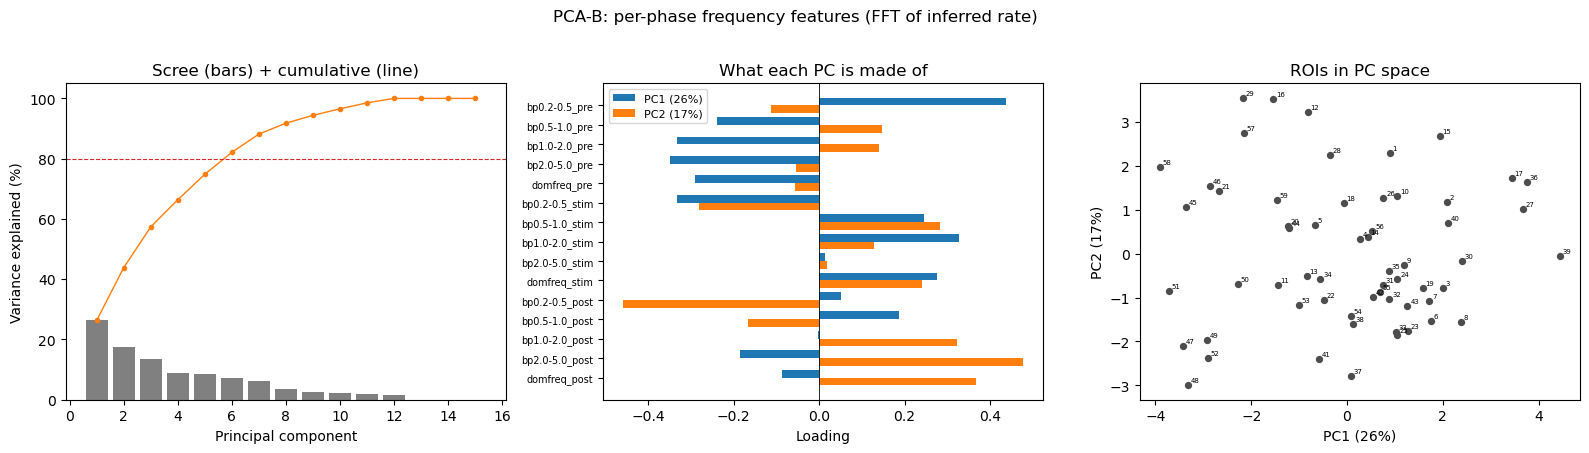


> Candidate cuts (pick one for FREQ_CUT_HEIGHT in §5 0, or accept the auto choice):
   height   gap  smallest  largest                      sizes
k                                                            
2   15.07  3.84        27       32                   [32, 27]
3   13.04  0.22         6       32                [32, 21, 6]
4   12.11  1.63         6       23             [23, 21, 9, 6]
5   10.00  2.60         6       23          [23, 14, 9, 7, 6]
6    8.69  0.01         2       23       [23, 14, 7, 7, 6, 2]
7    7.80  1.77         2       23     [23, 9, 7, 7, 6, 5, 2]
8    6.91  0.02         2       18  [18, 9, 7, 7, 6, 5, 5, 2]


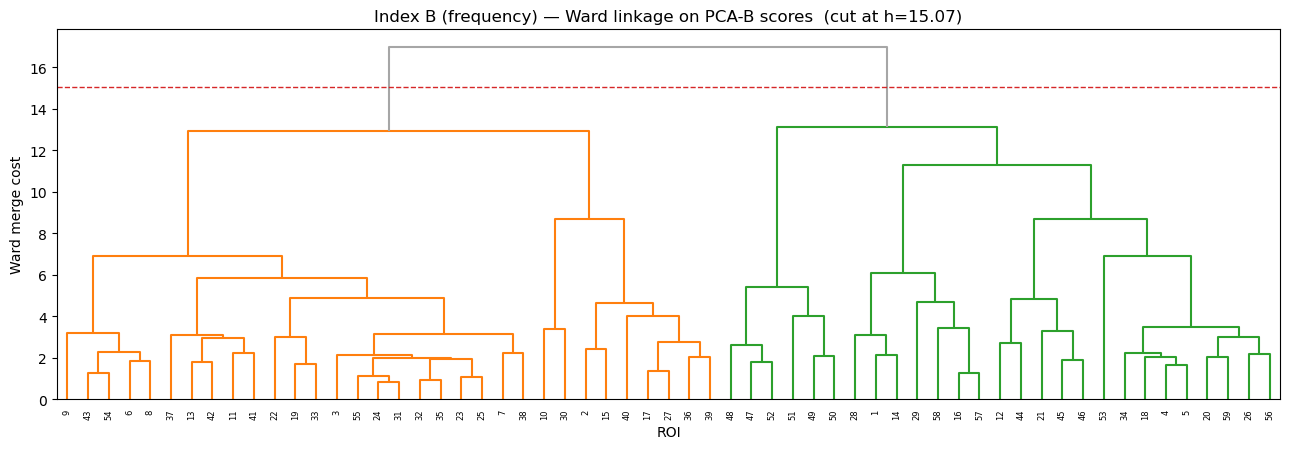

> Cut at h=15.07 -> 2 group(s): F1 n=32, F2 n=27

=== Frequency groups (Index B) ===
FFT of CASCADE inferred rate | Spinal_cord_excitatory_30Hz_smoothing50ms | bands [(0.2, 0.5), (0.5, 1.0), (1.0, 2.0), (2.0, 5.0)] Hz
       n_rois  domfreq_pre topband_pre  domfreq_stim topband_stim  domfreq_post topband_post
group                                                                                       
F1         32        0.262  0.2-0.5 Hz         0.519   0.5-1.0 Hz         0.464   0.2-0.5 Hz
F2         27        0.319  0.2-0.5 Hz         0.430   0.2-0.5 Hz         0.874   2.0-5.0 Hz
  F1: ROIs 2, 3, 6, 7, 8, 9, 10, 11, 13, 15, 17, 19, 22, 23, 24, 25, 27, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 54, 55
  F2: ROIs 1, 4, 5, 12, 14, 16, 18, 20, 21, 26, 28, 29, 34, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 56, 57, 58, 59

=== Rate groups vs frequency groups ===
freq group  F1  F2
rate group        
G1          30  26
G2           2   1

> Adjusted Rand index = -0.007  (1 = identica

In [56]:
# §5 x. PCA-B on the frequency features, cut the same way, then read the frequency
# grouping against the rate grouping from §5 viii.
pca_freq, scores_freq, npc_freq, Z_freq = at.grouping.pca_and_linkage(
    freq_features, PCA_VAR_TARGET)
print(f"> PCA-B: {freq_features.shape[1]} features -> {npc_freq} PC(s) "
      f"for {100 * pca_freq.explained_variance_ratio_[:npc_freq].sum():.0f}% of variance")

at.plots.pca_summary(pca_freq, scores_freq, freq_features, roi_ids,
                     "PCA-B: per-phase frequency features (FFT of inferred rate)",
                     PCA_VAR_TARGET)

print("\n> Candidate cuts (pick one for FREQ_CUT_HEIGHT in §5 0, or accept the auto choice):")
print(at.grouping.cut_candidates(Z_freq, MAX_K).to_string())

cut_freq = FREQ_CUT_HEIGHT if FREQ_CUT_HEIGHT is not None else at.grouping.suggest_cut(
    Z_freq, MAX_K, MIN_GROUP_SIZE, MAX_GROUP_FRAC)
at.plots.dendrogram_plot(Z_freq, roi_ids,
                         "Index B (frequency) — Ward linkage on PCA-B scores", cut_freq)
freq_groups = at.grouping.cut_tree(Z_freq, cut_freq, roi_ids, MAX_GROUP_FRAC,
                                   label="frequency", prefix="F")

freq_summary = at.features.freq_group_summary(freq_features, freq_groups, PHASE_ORDER, FREQ_BANDS)
print("\n=== Frequency groups (Index B) ===")
print(f"FFT of CASCADE inferred rate | {MODEL_NAME} | bands {FREQ_BANDS} Hz")
print(freq_summary.to_string())
at.grouping.print_membership(freq_groups, roi_ids, prefix="F")

print("\n=== Rate groups vs frequency groups ===")
contingency, ari = at.grouping.compare_partitions(rate_groups, freq_groups)

freq_features.to_csv(ANALYSIS_DIR / "freq_features.csv")
pd.DataFrame({"roi": roi_ids, "rate_group": rate_groups, "freq_group": freq_groups}).to_csv(
    ANALYSIS_DIR / "roi_groups.csv", index=False)
print(f"\n> Saved freq_features.csv and roi_groups.csv -> {ANALYSIS_DIR}")

### Caveats — read before quoting any number above

- **Single trial, n = 1 per neuron per phase.** Everything above is descriptive. There are no
  repeats to average over, so no inferential statistic applies and no p-value should be
  attached to any group difference.
- **CASCADE was trained on cortical V1 GCaMP8 (DS30–32).** No paired Ca²⁺/ephys ground truth
  exists for DRG (CLAUDE.md App.A §8), so this cross-cell-type transfer is *untested*. Report
  **relative** or **burst** rate — never absolute spike counts.
- **Acquisition sets the ceiling, not the algorithm.** 10 Hz sampling → 5 Hz Nyquist. The 5 s
  stimulus phase gives 0.2 Hz frequency resolution, so anything slower than 0.2 Hz is
  invisible *within that phase by construction*, not absent from the biology.
- **Resampling to reach a model's training rate creates no new information.** Running a 30 Hz
  model means the 10 Hz traces are interpolated 3×; the extra frames are a smooth function of
  the real ones. The model sees a signal cleaner than anything in its training set, and the
  inferred rate is resampled straight back to 10 Hz. Temporal resolution remains 10 Hz
  throughout. Noise levels are measured *before* resampling for exactly this reason — measured
  after, they read ~3× too clean and every ROI is routed to the wrong ensemble.
- **The post phase contains the indicator decay tail** of the stimulus response. Elevated
  post-stimulus values are not by themselves evidence of new firing. Deconvolving to a rate
  before summarising mitigates this; it does not eliminate it.
- **F0 = mean of the first `BASELINE_SLIDES` frames (0–2 s)**, so pre-phase features are taken
  from 2–10 s. A fixed F0 also bakes photobleaching drift into dF/F as a slow ramp.
- **ΔF/F amplitude is not a rate proxy** (CLAUDE.md App.A §11). The `dff_*` columns are
  descriptive only and are deliberately excluded from both PCAs.
- **Inference-target ambiguity.** For a DRG soma, T-junction filtering means the inferred rate
  is closer to a *somatic-invasion* rate than to the peripheral spike train (CLAUDE.md App.A
  §9/§11) — and the two diverge exactly at the high rates of interest.
- **A group is not a cell type.** These are response-pattern groups from one recording, not
  molecularly or physiologically defined classes.

## **-. Archive**

`4. i.`

In [ ]:
'''# STD projection: highlights temporally-fluctuating (active) pixels better than
# the max projection, which only shows consistently-bright pixels. Subsampled
# the same way as the max projection (every 5th frame) -- the per-frame
# denoise+motion-correction pipeline is too expensive to reduce over all 3220
# frames. Computed eagerly (unlike preprocessed_max_stack) because the same
# array is reused for saving + histogramming below.
preprocessed_std_stack = preprocessed_stack[::5].std(axis=0).compute()
print("> STD projection complete:", preprocessed_std_stack.shape, preprocessed_std_stack.dtype)

viewer.add_image(preprocessed_std_stack, name="preprocessed_std")'''

> STD projection complete: (1024, 1376) float32


<Image layer 'preprocessed_std' at 0x3078c2110>

> Saved STD projection -> /Users/leolopster/Desktop/spike_inference/_projections/Debi_DRG_std_projection.tiff


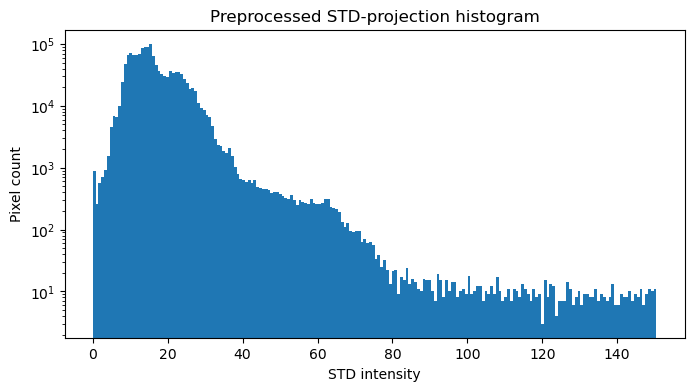

In [ ]:
'''# Save the STD projection locally and check its intensity distribution.

PROJECTIONS_DIR = Path("/Users/leolopster/Desktop/spike_inference/_projections")
PROJECTIONS_DIR.mkdir(exist_ok=True)

dataset_tag = data_dir.name.split("-")[0]  # "Debi_DRG" from "Debi_DRG-Streamtodisk-...imgdir"
std_projection_path = PROJECTIONS_DIR / f"{dataset_tag}_std_projection.tiff"

tifffile.imwrite(std_projection_path, preprocessed_std_stack)
print(f"> Saved STD projection -> {std_projection_path}")

# QC: pixel-intensity distribution, used to pick contrast/threshold before
# manually painting ROIs on top of this layer.
plt.figure(figsize=(8, 4))
plt.hist(preprocessed_std_stack.ravel(), bins=200)
plt.yscale('log')
plt.xlabel("STD intensity")
plt.ylabel("Pixel count")
plt.title("Preprocessed STD-projection histogram")
plt.show()'''

`4. iv.`

In [ ]:
### Deprecated. Use mean fluorescence of the first N-seconds as F0 instead.
'''
# dF/F per ROI using a rolling low-percentile baseline (CLAUDE.md 3): F0(t) is
# the BASELINE_PERCENTILE-th percentile of the ROI's own trace over a sliding
# ~BASELINE_WINDOW_S window, so slow drift / photobleaching across the ~5 min
# recording is tracked rather than baked into a single fixed baseline.
from scipy.ndimage import percentile_filter

BASELINE_PERCENTILE = 8   # low percentile approximates the inactive-baseline level
BASELINE_WINDOW_S = 45    # rolling window length (s)


def compute_dff(trace, times_s, percentile=BASELINE_PERCENTILE, window_s=BASELINE_WINDOW_S):
    dt = np.median(np.diff(times_s))
    win = max(3, int(round(window_s / dt)))
    f0 = percentile_filter(trace, percentile=percentile, size=win, mode="nearest")
    # preprocessed traces are background-subtracted + clipped at 0, so F0 can sit
    # near zero; floor it to keep dF/F finite.
    f0 = np.clip(f0, 1e-3, None)
    return (trace - f0) / f0


roi_ids = sorted(roi_traces)
dff_traces = {roi_id: compute_dff(roi_traces[roi_id], times_s) for roi_id in roi_ids}
dff_matrix = np.vstack([dff_traces[roi_id] for roi_id in roi_ids])  # (n_rois, n_timepoints)
print(f"> Computed dF/F for {len(roi_ids)} ROI(s); "
      f"dF/F range [{dff_matrix.min():.2f}, {dff_matrix.max():.2f}]")
'''


> Computed dF/F for 59 ROI(s); dF/F range [-0.12, 1.16]
